# Phase 1 — Data Contract, Labels, and Model Bases

In [1]:
# If needed once in this environment:
# %pip install python-dotenv sqlalchemy pyodbc pandas numpy scikit-learn lifelines

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from lifelines import CoxPHFitter
except ImportError:
    CoxPHFitter = None

sys.path.insert(0, '..')

from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_temp_table

In [2]:
# Paths
project_root = Path.cwd().resolve().parent  # .../yieldCurve_augmenting
env_path = project_root / '.env'
sql_path = project_root / 'sql_scripts' / 'jcx_raw_harvey_v14.sql'  # v14 = v13 + underwriting risk bands

# Load SQL and execute temp-table workflow
engine = create_db_engine(env_path)
setup_sql = read_sql_file(sql_path)

raw_df = execute_sql_and_read_temp_table(engine, setup_sql, '#t17_combined')

print('SQL loaded from:', sql_path)
print('Using env file:', env_path)
print('raw_df shape:', raw_df.shape)
raw_df.head()

SQL loaded from: /Users/starsrain/2025_concord/yieldCurve_augmenting/sql_scripts/jcx_raw_harvey_v14.sql
Using env file: /Users/starsrain/2025_concord/yieldCurve_augmenting/.env
raw_df shape: (1011734, 33)


,Application_ID,PortFolioID,LoanID,InstallmentNumber,InstallRealizedPayment,installStatus,iPaymentMode,TotalInstallsNumber,InstallmentDueDate,PaymentDate,...,AppYear,AppMonth,AppWeek,LoanStatus,CustType,Frequency,OriginatedAmount,OriginationDate,DM_Band_Name,CM_Band_Name
0,71851536,1,I1536952-0,1,0.0,111,144,6,2023-01-13,2023-01-13,...,2023,1,2,D,RETURN,S,250.0,2023-01-10,DM07,CM01
1,71851536,1,I1536952-0,2,75.0,111,144,6,2023-02-01,2023-02-01,...,2023,1,2,D,RETURN,S,250.0,2023-01-10,DM07,CM01
2,71851536,1,I1536952-0,3,75.0,111,144,6,2023-02-15,2023-02-15,...,2023,1,2,D,RETURN,S,250.0,2023-01-10,DM07,CM01
3,71851536,1,I1536952-0,4,75.0,111,144,6,2023-03-01,2023-03-01,...,2023,1,2,D,RETURN,S,250.0,2023-01-10,DM07,CM01
4,71851536,1,I1536952-0,5,125.0,111,144,6,2023-03-15,2023-03-15,...,2023,1,2,D,RETURN,S,250.0,2023-01-10,DM07,CM01


# Phase 1 — Data Contract, Labels, and Model Bases

Goal of this phase (no modeling yet):

1. **Validate** the v13 extract has the columns we need and coerce dtypes.
2. **Derive loan-level labels** straight from SQL flags (no Python re-derivation):
   - `payoff_type ∈ {FPD, SPD, TPD, 4PD, 5PD, LatePD, Clean_early, Clean_full, Immature, DENY_NEW, ALL_VOIDED}`.
3. Build three tidy modeling bases:
   - `loan_base`  — one row per loan (Stage A domain).
   - `seq_base`   — one row per (loan × normal installment) with lagged features (Stage B domain).
   - `stage_c_base` — delinquent loans with arrangement / 3rd-party realized payments (Stage C domain).
4. **Time-split**: holdout = most recent 20% of originations (among matured loans).

Leakage discipline (per design):

- Stage A features use origination-time only (no xPD flags as features).
- Stage B features use shifted/lagged values up to installment `k-1`.
- Terminal flags (`isLoanDefault`, `LoanPaidOffThisInstall`, `isInstallDefault`) are **targets only**.

In [3]:
# Data contract + dtype coercion

EXPECTED_COLS = [
    'Application_ID', 'PortFolioID', 'LoanID', 'InstallmentNumber',
    'InstallRealizedPayment', 'installStatus', 'iPaymentMode',
    'TotalInstallsNumber', 'InstallmentDueDate', 'PaymentDate',
    'isRecentLoan', 'LoanPaidOffThisInstall', 'isLoanDefault',
    'isInstallDefault', 'ThirdPartyCollected', 'PartialCollected',
    'InstallCollected', 'EarlyCollected', 'isDenyNew', 'isAllVoided',
    'isArrangementInstall', 'is3rdPartyInstall', 'TotalRealizedPayment',
    'AppYear', 'AppMonth', 'AppWeek', 'LoanStatus', 'CustType', 'Frequency',
    'OriginatedAmount', 'OriginationDate',
    'DM_Band_Name', 'CM_Band_Name',  # v14: underwriting risk bands (ScoredApplications)
]

missing = [c for c in EXPECTED_COLS if c not in raw_df.columns]
if missing:
    raise ValueError(f'raw_df missing expected columns: {missing}')

INT_COLS = [
    'InstallmentNumber', 'installStatus', 'iPaymentMode', 'TotalInstallsNumber',
    'isRecentLoan', 'LoanPaidOffThisInstall', 'isLoanDefault', 'isInstallDefault',
    'ThirdPartyCollected', 'PartialCollected', 'InstallCollected', 'EarlyCollected',
    'isDenyNew', 'isAllVoided', 'isArrangementInstall', 'is3rdPartyInstall',
    'AppYear', 'AppMonth', 'AppWeek',
]
FLOAT_COLS = ['InstallRealizedPayment', 'TotalRealizedPayment', 'OriginatedAmount']
DATE_COLS = ['InstallmentDueDate', 'PaymentDate', 'OriginationDate']

for c in INT_COLS:
    raw_df[c] = pd.to_numeric(raw_df[c], errors='coerce').fillna(0).astype(int)
for c in FLOAT_COLS:
    raw_df[c] = pd.to_numeric(raw_df[c], errors='coerce').astype(float)
for c in DATE_COLS:
    raw_df[c] = pd.to_datetime(raw_df[c], errors='coerce')

raw_df['CustType'] = raw_df['CustType'].astype(str).str.upper().str.strip()
raw_df['LoanStatus'] = raw_df['LoanStatus'].astype(str).str.upper().str.strip()
raw_df['Frequency'] = raw_df['Frequency'].astype(str).str.upper().str.strip()

# Risk bands: strip whitespace, leave original casing alone (scoring team vocabulary).
# Missing bands -> 'UNKNOWN' so downstream categorical encoders don't produce -1 codes.
for c in ['DM_Band_Name', 'CM_Band_Name']:
    raw_df[c] = raw_df[c].where(raw_df[c].notna(), 'UNKNOWN')
    raw_df[c] = raw_df[c].astype(str).str.strip().replace({'': 'UNKNOWN', 'nan': 'UNKNOWN', 'None': 'UNKNOWN'})

# Drop accidental duplicate rows at the (loan × installment × payment mode) grain.
before = len(raw_df)
raw_df = raw_df.drop_duplicates(['LoanID', 'InstallmentNumber', 'iPaymentMode'])
after = len(raw_df)
print(f'dropped {before - after} duplicate rows at (LoanID, InstallmentNumber, iPaymentMode) grain')

# Sanity checks
assert raw_df['LoanID'].notna().all(), 'LoanID has nulls'
assert raw_df['InstallmentNumber'].ge(1).all(), 'InstallmentNumber < 1 detected'
assert set(raw_df['iPaymentMode'].unique()) <= {144, 679, 685}, 'unexpected iPaymentMode values'

print('rows:', len(raw_df), '| loans:', raw_df['LoanID'].nunique())
print('iPaymentMode counts:\n', raw_df['iPaymentMode'].value_counts().sort_index())
print('CustType counts:\n', raw_df['CustType'].value_counts())

dropped 12 duplicate rows at (LoanID, InstallmentNumber, iPaymentMode) grain
rows: 1011722 | loans: 198929
iPaymentMode counts:
 iPaymentMode
144    969913
679     37139
685      4670
Name: count, dtype: int64
CustType counts:
 CustType
RETURN    511548
NEW       500174
Name: count, dtype: int64


## Frequency normalization

Native frequencies from SQL: `W` weekly, `B` bi-weekly, `S` semi-monthly, `M` monthly.
Business grouping used in presentations rolls `B + W → W` (see `jcx_2026_xpd_V1.ipynb`). We keep both the 4-bucket native view and the 3-bucket business view so modeling can pick whichever is more stable.

In [4]:
# Frequency normalization
FREQ_NATIVE_MAP = {
    'W': 'W', 'WEEKLY': 'W', 'WEEK': 'W', '1': 'W', '4': 'W',
    'B': 'B', 'BIWEEKLY': 'B', 'BI-WEEKLY': 'B',
    'S': 'S', 'SEMI': 'S', 'SEMIMONTHLY': 'S', 'SEMI-MONTHLY': 'S', '2': 'S', '5': 'S',
    'M': 'M', 'MONTHLY': 'M', '3': 'M', '6': 'M',
}
# Business 3-group: bi-weekly (B) and semi-monthly (S) collapse into 'B'.
# Final buckets: W, B, M.
FREQ_BIZ3_MAP = {'W': 'W', 'B': 'B', 'S': 'B', 'M': 'M'}

raw_df['Frequency_norm'] = raw_df['Frequency'].map(FREQ_NATIVE_MAP)
raw_df['Frequency_group3'] = raw_df['Frequency_norm'].map(FREQ_BIZ3_MAP)

print('Frequency_norm:\n', raw_df['Frequency_norm'].value_counts(dropna=False))
print('Frequency_group3:\n', raw_df['Frequency_group3'].value_counts(dropna=False))

Frequency_norm:
 Frequency_norm
B      560478
W      204496
S      129204
M      117527
NaN        17
Name: count, dtype: int64
Frequency_group3:
 Frequency_group3
B      689682
W      204496
M      117527
NaN        17
Name: count, dtype: int64


## Loan-level label derivation

For each loan we read v13's installment-level flags on the **normal payment stream** (`iPaymentMode = 144`) and derive:

- `first_default_inst` = `InstallmentNumber` where `isLoanDefault = 1` (the **terminal** default installment; at most one row per loan). This matches the xPD rate convention in `#monthly_summary` / `#monthly_summary_new` (see v13 §7, `FPD_Rate = Σ isLoanDefault @ inst 1 / eligible @ inst 1`).
- `paidoff_inst`       = min `InstallmentNumber` where `LoanPaidOffThisInstall = 1`.

> `isInstallDefault` (any installment with a bad status — can be transient if the loan later recovered) is **not** used for xPD labels. We only use it as a behavioral distress signal inside Stage B lagged features.
- `is_deny_new_loan`   = loan-level max of `isDenyNew`.
- `is_all_voided_loan` = loan-level max of `isAllVoided`.
- `is_recent_loan`     = loan-level max of `isRecentLoan`.

`payoff_type` is assigned in priority order:

| Priority | Condition | Label |
|---|---|---|
| 1 | `is_deny_new_loan = 1` | `DENY_NEW` (excluded from training) |
| 2 | `is_all_voided_loan = 1` | `ALL_VOIDED` (excluded from training) |
| 3 | `first_default_inst = 1` | `FPD` |
| 4 | `first_default_inst = 2` | `SPD` |
| 5 | `first_default_inst = 3` | `TPD` |
| 6 | `first_default_inst = 4` | `4PD` |
| 7 | `first_default_inst = 5` | `5PD` |
| 8 | `first_default_inst ≥ 6` | `LatePD` |
| 9 | `paidoff_inst < TotalInstallsNumber` | `Clean_early` |
| 10 | `paidoff_inst = TotalInstallsNumber` | `Clean_full` |
| else | everything else | `Immature` (excluded from training) |

**Training eligibility** requires a terminal `payoff_type` (not `Immature / DENY_NEW / ALL_VOIDED`), `isRecentLoan = 0`, and a non-null `OriginatedAmount`.

In [5]:
# Loan-level label derivation from v13 flags on the normal (iPaymentMode=144) stream.
normal = raw_df[raw_df['iPaymentMode'] == 144].copy()

def _first_inst_where(df, flag_col):
    mask = df[flag_col] == 1
    if not mask.any():
        return pd.Series(dtype='Int64')
    return (
        df.loc[mask]
        .groupby('LoanID')['InstallmentNumber']
        .min()
        .astype('Int64')
    )

# xPD labels follow the #monthly_summary convention: isLoanDefault = 1 at installment k => kPD.
# isLoanDefault appears at most once per loan (the terminal default row).
first_default_inst = _first_inst_where(normal, 'isLoanDefault').rename('first_default_inst')
paidoff_inst       = _first_inst_where(normal, 'LoanPaidOffThisInstall').rename('paidoff_inst')

loan_flags = (
    normal.groupby('LoanID', as_index=False)
    .agg(
        is_deny_new_loan=('isDenyNew', 'max'),
        is_all_voided_loan=('isAllVoided', 'max'),
        is_recent_loan=('isRecentLoan', 'max'),
        TotalInstallsNumber=('TotalInstallsNumber', 'max'),
        AppYear=('AppYear', 'first'),
        AppWeek=('AppWeek', 'first'),
    )
)
loan_flags['ApplicationDate'] = (
    pd.to_datetime(loan_flags['AppYear'].astype(str) + '-01-01')
    + pd.to_timedelta((loan_flags['AppWeek'] - 1) * 7, unit='D')
)
# Drop the app-timing columns now that ApplicationDate is built: loan_attrs (from raw_df)
# is the single source of truth for AppYear / AppWeek downstream, and keeping them here
# would cause _x/_y suffixing on the merge into loan_base.
loan_flags = loan_flags.drop(columns=['AppYear', 'AppWeek'])
loan_flags = (
    loan_flags
    .merge(first_default_inst, on='LoanID', how='left')
    .merge(paidoff_inst, on='LoanID', how='left')
)

def _payoff_type(row):
    if row['is_deny_new_loan'] == 1:
        return 'DENY_NEW'
    if row['is_all_voided_loan'] == 1:
        return 'ALL_VOIDED'
    d = row['first_default_inst']
    if pd.notna(d):
        d = int(d)
        if d == 1: return 'FPD'
        if d == 2: return 'SPD'
        if d == 3: return 'TPD'
        if d == 4: return '4PD'
        if d == 5: return '5PD'
        return 'LatePD'
    p = row['paidoff_inst']
    t = row['TotalInstallsNumber']
    if pd.notna(p) and pd.notna(t):
        return 'Clean_early' if int(p) < int(t) else 'Clean_full'
    return 'Immature'

loan_flags['payoff_type'] = loan_flags.apply(_payoff_type, axis=1)

TERMINAL_BUCKETS = {'FPD', 'SPD', 'TPD', '4PD', '5PD', 'LatePD', 'Clean_early', 'Clean_full'}
MIN_LOAN_AGE_DAYS = 120  # exclude vintages too young to have had a fair chance to mature
app_cutoff = pd.Timestamp.today().normalize() - pd.Timedelta(days=MIN_LOAN_AGE_DAYS)

loan_flags['is_training_eligible'] = (
    loan_flags['payoff_type'].isin(TERMINAL_BUCKETS)
    & (loan_flags['is_recent_loan'] == 0)
    & (loan_flags['ApplicationDate'] < app_cutoff)
)

print('payoff_type distribution (all loans):')
print(loan_flags['payoff_type'].value_counts(dropna=False))
print(f'\napp-date cutoff (applied before): {app_cutoff.date()}  (~{MIN_LOAN_AGE_DAYS}-day min age)')
print('training-eligible loans:', int(loan_flags['is_training_eligible'].sum()))

payoff_type distribution (all loans):
payoff_type
Clean_full     105003
LatePD          21545
FPD             17590
SPD             15365
TPD             11126
Immature        10131
4PD              8919
5PD              8513
DENY_NEW          513
ALL_VOIDED        221
Clean_early         3
Name: count, dtype: int64

app-date cutoff (applied before): 2025-12-25  (~120-day min age)
training-eligible loans: 179528


## Build `loan_base` (Stage A domain)

One row per loan, carrying:

- **Origination attributes** (Stage A features): `CustType`, `Frequency`, `AppYear/Month/Week`, `log_orig_amt`, month cyclic encoding, portfolio.
- **Targets** (never features): `payoff_type`, `first_default_inst`, `paidoff_inst`, `payin_ratio_realized = TotalRealizedPayment / OriginatedAmount`.
- **Scope flags**: `is_training_eligible`, `is_holdout` (most recent 20% of originations among matured loans).

In [6]:
# Build loan_base (one row per loan).
loan_attrs = (
    raw_df.groupby('LoanID', as_index=False)
    .agg(
        PortFolioID=('PortFolioID', 'first'),
        Application_ID=('Application_ID', 'first'),
        OriginatedAmount=('OriginatedAmount', 'first'),
        OriginationDate=('OriginationDate', 'min'),
        TotalRealizedPayment=('TotalRealizedPayment', 'first'),
        AppYear=('AppYear', 'first'),
        AppMonth=('AppMonth', 'first'),
        AppWeek=('AppWeek', 'first'),
        LoanStatus=('LoanStatus', 'first'),
        CustType=('CustType', 'first'),
        Frequency=('Frequency', 'first'),
        Frequency_norm=('Frequency_norm', 'first'),
        Frequency_group3=('Frequency_group3', 'first'),
        DM_Band_Name=('DM_Band_Name', 'first'),
        CM_Band_Name=('CM_Band_Name', 'first'),
    )
)

loan_base = loan_attrs.merge(loan_flags, on='LoanID', how='left')

# Realized payin ratio (target / validation only, not a feature).
loan_base['payin_ratio_realized'] = (
    loan_base['TotalRealizedPayment'] / loan_base['OriginatedAmount'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Stage A feature encodings (origination-time only).
loan_base['CustType_bin']     = (loan_base['CustType'] == 'RETURN').astype(int)
loan_base['Frequency_enc']    = loan_base['Frequency_norm'].astype('category').cat.codes
loan_base['Frequency3_enc']   = loan_base['Frequency_group3'].astype('category').cat.codes
loan_base['log_orig_amt']     = np.log1p(loan_base['OriginatedAmount'].clip(lower=0).fillna(0))
loan_base['month_sin']        = np.sin(2 * np.pi * loan_base['AppMonth'].fillna(1) / 12.0)
loan_base['month_cos']        = np.cos(2 * np.pi * loan_base['AppMonth'].fillna(1) / 12.0)
loan_base['week_sin']         = np.sin(2 * np.pi * loan_base['AppWeek'].fillna(1) / 52.0)
loan_base['week_cos']         = np.cos(2 * np.pi * loan_base['AppWeek'].fillna(1) / 52.0)

# Underwriting risk bands (v14): bucket-only form for ops portability.
# Preserve original string labels; encode as categorical integer codes for XGBoost.
# Nulls were coerced to 'UNKNOWN' upstream so codes are >= 0 everywhere.
loan_base['DM_Band_Name']     = loan_base['DM_Band_Name'].fillna('UNKNOWN').astype(str)
loan_base['CM_Band_Name']     = loan_base['CM_Band_Name'].fillna('UNKNOWN').astype(str)
loan_base['DM_Band_enc']      = loan_base['DM_Band_Name'].astype('category').cat.codes
loan_base['CM_Band_enc']      = loan_base['CM_Band_Name'].astype('category').cat.codes

# Time-based split: holdout = most recent 20% of originations, computed on matured loans only
# to avoid the holdout being dominated by immature loans that won't have labels.
matured_dates = loan_base.loc[loan_base['is_training_eligible'], 'OriginationDate'].dropna()
if matured_dates.empty:
    cutoff_date = loan_base['OriginationDate'].quantile(0.80)
else:
    cutoff_date = matured_dates.quantile(0.80)
loan_base['is_holdout'] = loan_base['OriginationDate'] >= cutoff_date

STAGE_A_FEATURES = [
    'CustType_bin',
    'Frequency_enc',
    'log_orig_amt',
    'AppYear',
    'month_sin', 'month_cos',
    'week_sin', 'week_cos',
    'PortFolioID',
    'DM_Band_enc',  # v14: underwriting DM risk band (bucketed score)
    'CM_Band_enc',  # v14: underwriting CM risk band (bucketed score)
]

print('loan_base shape:', loan_base.shape)
print('cutoff_date (holdout starts):', pd.to_datetime(cutoff_date).date() if pd.notna(cutoff_date) else 'NaT')
print('\nholdout mask counts by training eligibility:')
print(pd.crosstab(loan_base['is_training_eligible'], loan_base['is_holdout']))
print('\npayoff_type x CustType (training-eligible only):')
print(pd.crosstab(
    loan_base.loc[loan_base['is_training_eligible'], 'payoff_type'],
    loan_base.loc[loan_base['is_training_eligible'], 'CustType'],
))
loan_base.head()

loan_base shape: (198929, 37)
cutoff_date (holdout starts): 2025-04-01

holdout mask counts by training eligibility:
is_holdout             False  True 
is_training_eligible               
False                   1251  18150
True                  143631  35897

payoff_type x CustType (training-eligible only):
CustType       NEW  RETURN
payoff_type               
4PD           5610    2975
5PD           5238    2995
Clean_early      2       1
Clean_full   26582   73468
FPD          12240    4303
LatePD       13674    7500
SPD           9848    4574
TPD           6926    3592


,LoanID,PortFolioID,Application_ID,OriginatedAmount,OriginationDate,TotalRealizedPayment,AppYear,AppMonth,AppWeek,LoanStatus,...,Frequency_enc,Frequency3_enc,log_orig_amt,month_sin,month_cos,week_sin,week_cos,DM_Band_enc,CM_Band_enc,is_holdout
0,I1529359-0,7,70945935,1500.0,2023-01-02,2109.68,2023,1,1,D,...,1,1,7.313887,0.5,0.866025,0.120537,0.992709,3,3,False
1,I1529362-0,1,71206268,600.0,2023-01-03,763.57,2023,1,1,D,...,3,2,6.398595,0.5,0.866025,0.120537,0.992709,3,6,False
2,I1529363-0,7,70945940,300.0,2023-01-03,358.50,2023,1,1,D,...,0,0,5.707110,0.5,0.866025,0.120537,0.992709,4,7,False
3,I1529364-0,1,71206272,500.0,2023-01-03,700.00,2023,1,1,D,...,1,1,6.216606,0.5,0.866025,0.120537,0.992709,5,2,False
4,I1529365-0,6,85580965,1500.0,2023-01-01,2461.00,2023,1,1,D,...,2,0,7.313887,0.5,0.866025,0.120537,0.992709,5,8,False


## Risk-band QC (v14)

Before we trust `DM_Band_enc` / `CM_Band_enc` as Stage A features, verify:

1. **Join coverage** — what fraction of loans have a non-`UNKNOWN` band? A high `UNKNOWN` rate in a given cohort (e.g., RETURN customers) tells us the band is informative for only part of the book, and we may need to fall back to a `has_band` flag + interaction term.
2. **Label distribution** — how many distinct band levels exist, and is the mass reasonably spread? Extremely imbalanced bands (e.g., 99% in one level) carry no signal.
3. **Discrimination** — does xPD (FPD / SPD / TPD) rate vary monotonically across bands? If yes, the band is a real risk signal; if flat, the numeric model behind the band doesn't match our target.
4. **Stability across time / cohort** — do band definitions remain consistent across `AppYear`? A sudden shift in level mix suggests a scoring recalibration we'd need to handle.

Only after these checks pass should we promote the bands from "added" to "trusted." This cell is diagnostic — read the output before moving on.

In [7]:
# Risk-band diagnostic QC. Run against the full loan_base, then re-filter for training-eligible.
eligible = loan_base[loan_base['is_training_eligible']].copy()

def _band_qc(df, band_col, label):
    print(f'\n===== {label} ({band_col}) =====')
    n = len(df)
    known = (df[band_col] != 'UNKNOWN').sum()
    print(f'coverage: {known:,}/{n:,}  ({known/n:.1%} have a non-UNKNOWN band)')

    print(f'\nlevel distribution:')
    dist = df[band_col].value_counts(dropna=False)
    print(dist.to_string())

    # Coverage split by CustType — bands are typically scored at NEW origination only.
    print(f'\ncoverage by CustType:')
    cov = (
        df.assign(_has=(df[band_col] != 'UNKNOWN').astype(int))
          .groupby('CustType')['_has']
          .agg(['sum', 'count'])
    )
    cov['coverage'] = cov['sum'] / cov['count']
    print(cov.to_string())

    # xPD discrimination: for loans that reached installment 1, what's the FPD rate by band?
    # Use training-eligible subset so the numerator/denominator are well-defined.
    elig = df[df['is_training_eligible']].copy()
    if len(elig) == 0:
        print('\n(no training-eligible loans in this slice — skipping xPD breakdown)')
        return
    elig['is_FPD'] = (elig['payoff_type'] == 'FPD').astype(int)
    elig['is_SPD'] = (elig['payoff_type'] == 'SPD').astype(int)
    elig['is_any_default'] = elig['payoff_type'].isin({'FPD','SPD','TPD','4PD','5PD','LatePD'}).astype(int)
    by_band = elig.groupby(band_col).agg(
        n_loans=('LoanID', 'count'),
        FPD_rate=('is_FPD', 'mean'),
        SPD_rate=('is_SPD', 'mean'),
        AnyDefault_rate=('is_any_default', 'mean'),
    ).sort_values('AnyDefault_rate', ascending=False)
    print(f'\nxPD rates by band (training-eligible):')
    print(by_band.to_string(float_format=lambda x: f'{x:.1%}' if pd.notna(x) else ''))

    # Year-over-year stability: level mix per AppYear
    mix = (
        df.groupby(['AppYear', band_col])
          .size()
          .unstack(fill_value=0)
    )
    mix_pct = mix.div(mix.sum(axis=1), axis=0)
    print(f'\nlevel mix by AppYear (% of loans):')
    print(mix_pct.to_string(float_format=lambda x: f'{x:.1%}'))

_band_qc(loan_base, 'DM_Band_Name', 'DM Band')
_band_qc(loan_base, 'CM_Band_Name', 'CM Band')

# Cross-band co-occurrence: are DM and CM telling us the same thing or different things?
print('\n===== DM x CM co-occurrence (training-eligible) =====')
print(pd.crosstab(eligible['DM_Band_Name'], eligible['CM_Band_Name']))


===== DM Band (DM_Band_Name) =====
coverage: 178,608/198,929  (89.8% have a non-UNKNOWN band)

level distribution:
DM_Band_Name
DM04       53249
DM05       45356
DM06       26999
DM03       22255
UNKNOWN    20321
DM02       10831
DM01       10186
DM08        6393
DM07        3339

coverage by CustType:
             sum   count  coverage
CustType                          
NEW        76074   89561  0.849410
RETURN    102534  109368  0.937514

xPD rates by band (training-eligible):
              n_loans  FPD_rate  SPD_rate  AnyDefault_rate
DM_Band_Name                                              
DM01             9251     19.4%     12.8%            67.1%
DM03            21047     11.9%      9.9%            53.6%
UNKNOWN         13627     13.0%      9.7%            52.7%
DM02             9977     12.2%     10.0%            51.9%
DM04            49816     10.3%      9.1%            49.6%
DM05            42057      7.1%      6.9%            40.4%
DM06            24595      4.1%      5.0%  

## Build `seq_base` (Stage B domain)

One row per `(LoanID × InstallmentNumber)` on the normal payment stream (`iPaymentMode = 144`).

- **Current-row target**: `collected_flag_k = max(InstallCollected, EarlyCollected, PartialCollected, ThirdPartyCollected)` and `collected_amount_k = InstallRealizedPayment`.
- **Lagged features** (shifted by 1 within `LoanID`, so row at `k` sees only `1..k-1`):
  - `cum_payin_ratio_lag`  — the hero feature (Bavna's hypothesis).
  - `cum_collected_rate_lag`, `cum_partial_rate_lag`, `cum_3rdparty_rate_lag`, `cum_early_rate_lag`.
  - `had_arrangement_by_lag`, `had_3rdparty_by_lag` — picked up from `iPaymentMode ∈ {679, 685}` rows that occurred *before* the current installment's due date (per our Q3 decision).
  - `prior_distress_lag` — count of prior installments with `isInstallDefault = 1` (bad status code — voided, 3rd-party, closed-for-arrangement, etc., *whether or not* the loan eventually recovered). This is a **behavioral** signal, deliberately distinct from the xPD label which uses `isLoanDefault`.
  - `install_progress_lag = (k-1) / TotalInstallsNumber`.
  - `days_since_origination` at this installment's due date.

Terminal flags (`isLoanDefault`, `LoanPaidOffThisInstall`, `isInstallDefault`) stay on the row as **targets / evaluation aids**, never as features.

In [8]:
# Pre-compute per-loan timelines for arrangement (679) and 3rd-party (685) rows.
# We'll stamp each normal installment row with "had an arrangement/3rd-party event on or
# before this installment's due date" so Stage B sees it as a lagged behavioral signal.
aux = raw_df[raw_df['iPaymentMode'].isin([679, 685])].copy()
aux_events = aux[['LoanID', 'iPaymentMode', 'InstallmentDueDate']].dropna(subset=['InstallmentDueDate'])
arr_first = (
    aux_events.loc[aux_events['iPaymentMode'] == 679]
    .groupby('LoanID')['InstallmentDueDate'].min()
    .rename('first_arrangement_date')
)
tp_first = (
    aux_events.loc[aux_events['iPaymentMode'] == 685]
    .groupby('LoanID')['InstallmentDueDate'].min()
    .rename('first_3rdparty_date')
)

# Base: normal installment rows only.
seq = raw_df[raw_df['iPaymentMode'] == 144].copy()
seq = seq.sort_values(['LoanID', 'InstallmentNumber']).reset_index(drop=True)

# Targets at each installment.
collected_cols = ['InstallCollected', 'EarlyCollected', 'PartialCollected', 'ThirdPartyCollected']
seq['collected_flag_k']   = seq[collected_cols].max(axis=1).astype(int)
seq['collected_amount_k'] = seq['InstallRealizedPayment'].fillna(0.0)
seq['step_payin_ratio_k'] = (
    seq['collected_amount_k'] / seq['OriginatedAmount'].replace(0, np.nan)
).fillna(0.0)

# Join origination date + arrangement/3rd-party first-event dates.
seq = seq.merge(loan_base[['LoanID', 'OriginationDate']], on='LoanID', how='left', suffixes=('', '_loan'))
seq['OriginationDate'] = seq['OriginationDate'].fillna(seq['OriginationDate_loan'])
seq = seq.drop(columns=[c for c in ['OriginationDate_loan'] if c in seq.columns])
seq = seq.merge(arr_first, on='LoanID', how='left')
seq = seq.merge(tp_first, on='LoanID', how='left')

seq['days_since_origination'] = (seq['InstallmentDueDate'] - seq['OriginationDate']).dt.days

# Lagged running statistics within LoanID (shift by 1 so row k sees only 1..k-1).
g = seq.groupby('LoanID', sort=False)
seq['cum_collected_amt_lag']   = g['collected_amount_k'].cumsum().shift(1)
seq['cum_payin_ratio_lag']     = (
    seq['cum_collected_amt_lag'] / seq['OriginatedAmount'].replace(0, np.nan)
).fillna(0.0)
# Flip back to 0 where the shift produced NaN at k=1.
seq.loc[g.cumcount() == 0, 'cum_payin_ratio_lag'] = 0.0

for src, out in [
    ('collected_flag_k',     'cum_collected_rate_lag'),
    ('PartialCollected',     'cum_partial_rate_lag'),
    ('ThirdPartyCollected',  'cum_3rdparty_rate_lag'),
    ('EarlyCollected',       'cum_early_rate_lag'),
    # prior_distress_lag uses isInstallDefault (any bad-status installment, possibly transient)
    # as a behavioral signal. xPD labels use isLoanDefault separately (loan-level labels in cell 7).
    ('isInstallDefault',     'prior_distress_lag'),
]:
    # Expanding mean (or count for distress) of prior rows only.
    agg = 'sum' if out == 'prior_distress_lag' else 'mean'
    seq[out] = (
        g[src].transform(lambda s: s.shift(1).expanding().agg(agg))
        .fillna(0.0)
    )

seq['install_progress_lag'] = (
    (seq['InstallmentNumber'] - 1) / seq['TotalInstallsNumber'].replace(0, np.nan)
).fillna(0.0).clip(0, 1)

# Arrangement / 3rd-party flag: did an arrangement or 3rd-party event occur before this due date?
seq['had_arrangement_by_lag'] = (
    seq['first_arrangement_date'].notna()
    & (seq['first_arrangement_date'] < seq['InstallmentDueDate'])
).astype(int)
seq['had_3rdparty_by_lag'] = (
    seq['first_3rdparty_date'].notna()
    & (seq['first_3rdparty_date'] < seq['InstallmentDueDate'])
).astype(int)

# Carry loan-level encodings used by Stage B.
seq = seq.merge(
    loan_base[[
        'LoanID', 'CustType_bin', 'Frequency_enc', 'Frequency3_enc',
        'log_orig_amt', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
        'is_training_eligible', 'is_holdout', 'payoff_type',
    ]],
    on='LoanID', how='left',
)

STAGE_B_FEATURES = [
    'InstallmentNumber',
    'install_progress_lag',
    'days_since_origination',
    'cum_payin_ratio_lag',
    'cum_collected_rate_lag',
    'cum_partial_rate_lag',
    'cum_3rdparty_rate_lag',
    'cum_early_rate_lag',
    'prior_distress_lag',
    'had_arrangement_by_lag',
    'had_3rdparty_by_lag',
    'CustType_bin',
    'Frequency_enc',
    'log_orig_amt',
    'month_sin', 'month_cos',
]

seq_base = seq.copy()
print('seq_base shape:', seq_base.shape)
print('rows per loan (describe):')
print(seq_base.groupby('LoanID').size().describe())
print('\ncollected_flag_k mean by InstallmentNumber (first 10):')
print(
    seq_base[seq_base['InstallmentNumber'] <= 10]
    .groupby('InstallmentNumber')['collected_flag_k'].mean().round(3)
)
print('\nmean cum_payin_ratio_lag by InstallmentNumber (first 10):')
print(
    seq_base[seq_base['InstallmentNumber'] <= 10]
    .groupby('InstallmentNumber')['cum_payin_ratio_lag'].mean().round(3)
)
seq_base.head()

seq_base shape: (969913, 62)
rows per loan (describe):
count    198929.000000
mean          4.875674
std           4.866482
min           1.000000
25%           1.000000
50%           3.000000
75%           7.000000
max          28.000000
dtype: float64

collected_flag_k mean by InstallmentNumber (first 10):
InstallmentNumber
1     0.816
2     0.820
3     0.829
4     0.834
5     0.799
6     0.826
7     0.840
8     0.849
9     0.848
10    0.859
Name: collected_flag_k, dtype: float64

mean cum_payin_ratio_lag by InstallmentNumber (first 10):
InstallmentNumber
1     0.000
2     0.245
3     0.540
4     0.822
5     1.100
6     1.471
7     1.808
8     2.110
9     2.354
10    2.577
Name: cum_payin_ratio_lag, dtype: float64


,Application_ID,PortFolioID,LoanID,InstallmentNumber,InstallRealizedPayment,installStatus,iPaymentMode,TotalInstallsNumber,InstallmentDueDate,PaymentDate,...,Frequency_enc,Frequency3_enc,log_orig_amt,month_sin,month_cos,week_sin,week_cos,is_training_eligible,is_holdout,payoff_type
0,70945935,7,I1529359-0,1,2109.68,111,144,1,2023-02-03,2023-01-31,...,1,1,7.313887,0.5,0.866025,0.120537,0.992709,True,False,Clean_full
1,71206268,1,I1529362-0,1,95.00,111,144,2,2023-01-13,2023-01-13,...,3,2,6.398595,0.5,0.866025,0.120537,0.992709,True,False,Clean_full
2,71206268,1,I1529362-0,2,668.57,111,144,2,2023-01-20,2023-01-17,...,3,2,6.398595,0.5,0.866025,0.120537,0.992709,True,False,Clean_full
3,70945940,7,I1529363-0,1,358.50,111,144,1,2023-01-13,2023-01-12,...,0,0,5.707110,0.5,0.866025,0.120537,0.992709,True,False,Clean_full
4,71206272,1,I1529364-0,1,700.00,111,144,1,2023-01-31,2023-01-31,...,1,1,6.216606,0.5,0.866025,0.120537,0.992709,True,False,Clean_full


## Build `stage_c_base` (delinquent-recovery domain)

Population: loans with `LoanStatus ∈ {R, T, L}` (Returned Item / 3rd-Party / Debt Collection). For each such loan:

- `default_inst`: the installment with `isLoanDefault = 1` (terminal default row; matches xPD convention) on normal stream.
- `default_due_date`: due date of that installment (proxy for the default moment).
- `arrangement_realized`  = sum of `InstallRealizedPayment` on `iPaymentMode = 679` rows after default.
- `third_party_realized`  = sum of `InstallRealizedPayment` on `iPaymentMode = 685` rows after default.
- `recovery_realized`     = `arrangement_realized + third_party_realized`.
- `outstanding_at_default`= `OriginatedAmount − Σ normal-stream collected $ up to and including default_inst`.
- `days_since_default`    = snapshot `as_of_date` minus `default_due_date`.

We'll use this base in Phase 2 to fit a recovery curve by `(days_since_default bin × channel)`, replacing V1's hand-coded `stage_c_rate_map`.

In [9]:
# Build stage_c_base (delinquent recovery domain).
DELINQUENT_STATUSES = {'R', 'T', 'L'}

# Default event per loan: use isLoanDefault = 1 (terminal default row; matches xPD convention).
default_event = (
    seq_base.loc[seq_base['isLoanDefault'] == 1]
    .sort_values(['LoanID', 'InstallmentNumber'])
    .groupby('LoanID', as_index=False)
    .agg(
        default_inst=('InstallmentNumber', 'first'),
        default_due_date=('InstallmentDueDate', 'first'),
    )
)

# Normal-stream collected $ up to and including default installment -> outstanding at default.
paid_up_to_default = (
    seq_base.merge(default_event[['LoanID', 'default_inst']], on='LoanID', how='inner')
    .query('InstallmentNumber <= default_inst')
    .groupby('LoanID', as_index=False)['collected_amount_k'].sum()
    .rename(columns={'collected_amount_k': 'paid_by_default'})
)

# Arrangement + 3rd-party realized post-default.
aux_realized = raw_df[raw_df['iPaymentMode'].isin([679, 685])].copy()
aux_realized['InstallRealizedPayment'] = aux_realized['InstallRealizedPayment'].fillna(0.0)
aux_realized = aux_realized.merge(
    default_event[['LoanID', 'default_due_date']], on='LoanID', how='inner'
)
aux_realized['is_post_default'] = (
    aux_realized['InstallmentDueDate'] >= aux_realized['default_due_date']
).fillna(False)

aux_post = aux_realized[aux_realized['is_post_default']]
recovery_sums = (
    aux_post.groupby(['LoanID', 'iPaymentMode'], as_index=False)['InstallRealizedPayment']
    .sum()
    .pivot(index='LoanID', columns='iPaymentMode', values='InstallRealizedPayment')
    .rename(columns={679: 'arrangement_realized', 685: 'third_party_realized'})
    .reset_index()
    .fillna(0.0)
)
for c in ['arrangement_realized', 'third_party_realized']:
    if c not in recovery_sums.columns:
        recovery_sums[c] = 0.0

# Assemble stage_c_base over delinquent loans only.
stage_c_base = (
    loan_base[loan_base['LoanStatus'].isin(DELINQUENT_STATUSES)]
    [['LoanID', 'PortFolioID', 'OriginatedAmount', 'LoanStatus', 'OriginationDate',
      'CustType', 'Frequency_norm', 'is_holdout']]
    .merge(default_event, on='LoanID', how='left')
    .merge(paid_up_to_default, on='LoanID', how='left')
    .merge(recovery_sums[['LoanID', 'arrangement_realized', 'third_party_realized']],
           on='LoanID', how='left')
)

for c in ['paid_by_default', 'arrangement_realized', 'third_party_realized']:
    stage_c_base[c] = stage_c_base[c].fillna(0.0)

stage_c_base['recovery_realized'] = (
    stage_c_base['arrangement_realized'] + stage_c_base['third_party_realized']
)
stage_c_base['outstanding_at_default'] = (
    stage_c_base['OriginatedAmount'] - stage_c_base['paid_by_default']
).clip(lower=0.0)
stage_c_base['recovery_rate_realized'] = (
    stage_c_base['recovery_realized']
    / stage_c_base['outstanding_at_default'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Days since default (using max payment date across the whole extract as the snapshot).
snapshot_date = raw_df['PaymentDate'].max()
if pd.isna(snapshot_date):
    snapshot_date = pd.Timestamp.today().normalize()
stage_c_base['snapshot_date'] = snapshot_date
stage_c_base['days_since_default'] = (
    snapshot_date - stage_c_base['default_due_date']
).dt.days

print('snapshot_date (Stage C):', pd.to_datetime(snapshot_date).date())
print('stage_c_base shape:', stage_c_base.shape)
print('LoanStatus counts in Stage C pool:')
print(stage_c_base['LoanStatus'].value_counts())
print('\nobserved recovery rate by (LoanStatus):')
print(
    stage_c_base.groupby('LoanStatus')
    .agg(
        loans=('LoanID', 'nunique'),
        mean_recovery_rate=('recovery_rate_realized', 'mean'),
        mean_days_since_default=('days_since_default', 'mean'),
    ).round(3)
)
stage_c_base.head()

snapshot_date (Stage C): 2028-05-27
stage_c_base shape: (8717, 18)
LoanStatus counts in Stage C pool:
LoanStatus
R    7249
L    1468
Name: count, dtype: int64

observed recovery rate by (LoanStatus):
            loans  mean_recovery_rate  mean_days_since_default
LoanStatus                                                    
L            1468               0.029                 1281.262
R            7249               0.157                  993.825


,LoanID,PortFolioID,OriginatedAmount,LoanStatus,OriginationDate,CustType,Frequency_norm,is_holdout,default_inst,default_due_date,paid_by_default,arrangement_realized,third_party_realized,recovery_realized,outstanding_at_default,recovery_rate_realized,snapshot_date,days_since_default
0,I1529690-0,1,800.0,R,2023-01-03,NEW,B,False,5.0,2023-03-13,960.0,0.0,0.0,0.0,0.0,0.0,2028-05-27,1902.0
1,I1530089-0,6,900.0,R,2023-01-03,NEW,B,False,6.0,2023-02-24,990.0,0.0,0.0,0.0,0.0,0.0,2028-05-27,1919.0
2,I1530150-0,5,900.0,R,2023-01-03,NEW,W,False,1.0,2023-01-13,0.0,630.0,0.0,630.0,900.0,0.7,2028-05-27,1961.0
3,I1530176-0,1,900.0,R,2023-01-03,NEW,B,False,1.0,2023-01-13,0.0,0.0,0.0,0.0,900.0,0.0,2028-05-27,1961.0
4,I1530530-0,6,500.0,L,2023-01-03,NEW,B,False,11.0,2023-06-09,1600.0,0.0,0.0,0.0,0.0,0.0,2028-05-27,1814.0


## Phase 1 QC summary

Fast sanity bundle so we can confirm the three bases are well-formed before modeling in Phase 2:

- `loan_base` row count, holdout split, payoff_type distribution, and a reconciliation check that `TotalRealizedPayment` ≈ Σ normal-stream `InstallRealizedPayment`.
- `seq_base` row count, installments per loan distribution, and a leakage guard (all lagged feature values must be finite and computed from shifted rows only).
- `stage_c_base` row count, observed recovery rate, and any obvious gaps.

In [10]:
# Phase 1 QC bundle
print('=== loan_base ===')
print(f'loans total        : {len(loan_base):,}')
print(f'training eligible  : {int(loan_base["is_training_eligible"].sum()):,}')
print(f'  of which holdout : {int((loan_base["is_training_eligible"] & loan_base["is_holdout"]).sum()):,}')

# Payin reconciliation: normal-stream sum vs SQL TotalRealizedPayment per loan.
reconciliation = (
    seq_base.groupby('LoanID', as_index=False)['collected_amount_k'].sum()
    .rename(columns={'collected_amount_k': 'sum_from_installments'})
    .merge(loan_base[['LoanID', 'TotalRealizedPayment']], on='LoanID', how='left')
)
reconciliation['diff'] = (
    reconciliation['sum_from_installments'] - reconciliation['TotalRealizedPayment'].fillna(0.0)
)
recon_summary = reconciliation['diff'].describe(percentiles=[0.01, 0.5, 0.99])
print('\npayin reconciliation diff (sum_from_installments - TotalRealizedPayment):')
print(recon_summary.round(2))
n_mismatched = int((reconciliation['diff'].abs() > 1.0).sum())
print(f'loans with |diff| > $1: {n_mismatched:,} '
      f'({n_mismatched / len(reconciliation):.2%} of {len(reconciliation):,})')

print('\n=== seq_base ===')
print(f'rows               : {len(seq_base):,}')
print(f'unique loans       : {seq_base["LoanID"].nunique():,}')
print(f'training eligible rows : {int(seq_base["is_training_eligible"].sum()):,}')
lag_cols = [c for c in STAGE_B_FEATURES if c.endswith('_lag')] + ['cum_payin_ratio_lag']
print('\nlagged feature null rates (should all be 0):')
print(seq_base[lag_cols].isna().mean().round(4))
# Leakage sanity: at k=1, all cum_* lag features should equal 0.
k1 = seq_base[seq_base['InstallmentNumber'] == 1]
max_k1 = k1[[c for c in lag_cols if c.startswith('cum_') or c.startswith('prior_')]].abs().max().max()
print(f'max |lagged feature| at k=1 (should be 0.0): {max_k1:.6f}')

print('\n=== stage_c_base ===')
print(f'delinquent loans   : {len(stage_c_base):,}')
print(f'  with default_inst: {int(stage_c_base["default_inst"].notna().sum()):,}')
print(f'  recovery > 0     : {int((stage_c_base["recovery_realized"] > 0).sum()):,}')
print(f'mean recovery rate : {stage_c_base["recovery_rate_realized"].mean():.3f}')
print(f'median days since default: {stage_c_base["days_since_default"].median():.0f}')

print('\nPhase 1 complete. Exports ready: loan_base, seq_base, stage_c_base, STAGE_A_FEATURES, STAGE_B_FEATURES.')

=== loan_base ===
loans total        : 198,929
training eligible  : 179,528
  of which holdout : 35,897

payin reconciliation diff (sum_from_installments - TotalRealizedPayment):
count    198929.00
mean        -61.37
std         266.76
min       -3800.00
1%        -1500.00
50%           0.00
99%           0.00
max           0.00
Name: diff, dtype: float64
loans with |diff| > $1: 15,954 (8.02% of 198,929)

=== seq_base ===
rows               : 969,913
unique loans       : 198,929
training eligible rows : 885,213

lagged feature null rates (should all be 0):
install_progress_lag      0.0
cum_payin_ratio_lag       0.0
cum_collected_rate_lag    0.0
cum_partial_rate_lag      0.0
cum_3rdparty_rate_lag     0.0
cum_early_rate_lag        0.0
prior_distress_lag        0.0
had_arrangement_by_lag    0.0
had_3rdparty_by_lag       0.0
cum_payin_ratio_lag       0.0
dtype: float64
max |lagged feature| at k=1 (should be 0.0): 0.000000

=== stage_c_base ===
delinquent loans   : 8,717
  with default_inst

# Phase 2 — Stage A: origination-time multinomial classifier (MVP)

We collapse the 11-class `payoff_type` into 7 classes (FPD, SPD, TPD, LatePD, Clean, DENY_NEW, ALL_VOIDED) for the MVP. Merging `4PD`/`5PD` into `LatePD` and `Clean_early`/`Clean_full` into `Clean` keeps the target stable without sacrificing the xPD-timing story the pipeline needs.

Goal: fit XGBoost multinomial on the training slice, report log-loss + Brier + per-class calibration on the holdout slice. Output: `P(class | features)` callable for downstream simulation.


unmapped training-eligible rows after collapse: 0  (should be 0)

collapsed class counts (training-eligible):
payoff_type_collapsed
FPD            16543
SPD            14422
TPD            10518
LatePD         37992
Clean         100053
DENY_NEW           0
ALL_VOIDED         0
Name: count, dtype: int64

stage_a trained. train_rows=143,631  holdout_rows=35,897

holdout log-loss : 1.1172
holdout Brier    : 0.5522

per-class calibration (holdout):
        class  n_true  pred_mean  obs_rate
0         FPD    3686     0.0984    0.1027
1         SPD    3068     0.0830    0.0855
2         TPD    2408     0.0605    0.0671
3      LatePD    7720     0.1995    0.2151
4       Clean   19015     0.5585    0.5297
5    DENY_NEW       0     0.0001    0.0000
6  ALL_VOIDED       0     0.0001    0.0000


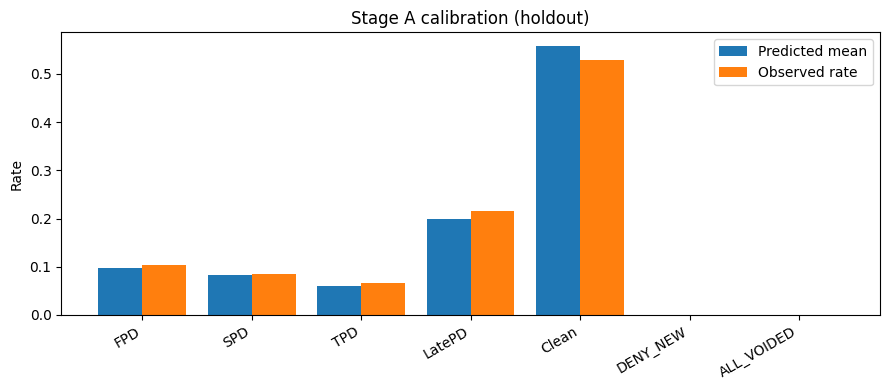

In [11]:
# Stage A: collapse target, fit, evaluate.
import sys, os
_UTIL_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _UTIL_PATH not in sys.path:
    sys.path.insert(0, _UTIL_PATH)

from util.projection_labels import collapse_payoff_type, PAYOFF_TYPE_COLLAPSED_ORDER
from util.projection_stage_a import fit_stage_a, predict_proba, evaluate_stage_a
from util.projection_plots import plot_stage_a_calibration

loan_base['payoff_type_collapsed'] = collapse_payoff_type(loan_base['payoff_type'])

# Sanity: collapse should map all training-eligible rows (no NaN).
n_unmapped = loan_base.loc[loan_base['is_training_eligible'], 'payoff_type_collapsed'].isna().sum()
print(f'unmapped training-eligible rows after collapse: {n_unmapped}  (should be 0)')
print('\ncollapsed class counts (training-eligible):')
print(
    loan_base.loc[loan_base['is_training_eligible'], 'payoff_type_collapsed']
    .value_counts().reindex(PAYOFF_TYPE_COLLAPSED_ORDER).fillna(0).astype(int)
)

stage_a = fit_stage_a(
    loan_base=loan_base,
    features=STAGE_A_FEATURES,
    target_col='payoff_type_collapsed',
)
print(f'\nstage_a trained. train_rows={stage_a.train_rows:,}  holdout_rows={stage_a.holdout_rows:,}')

a_eval = evaluate_stage_a(stage_a, loan_base)
print(f'\nholdout log-loss : {a_eval["log_loss"]:.4f}')
print(f'holdout Brier    : {a_eval["brier"]:.4f}')
print('\nper-class calibration (holdout):')
print(a_eval['per_class_calibration'].round(4))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
plot_stage_a_calibration(a_eval['per_class_calibration'], ax=ax)
plt.tight_layout(); plt.show()

# Phase 3 — Stage B: per-installment collection probability + amount (MVP)

LightGBM binary classifier for `P(collected_flag_k)` and LightGBM regressor for `E[$ | collected]`. We report classifier log-loss + accuracy, regressor MAE + R², and per-installment calibration. The output, `e_amount = P(collected) × E[$|collected]`, is what the simulator will eventually fold into per-installment trajectories (next iteration — in the MVP we consume Stage A's class-conditional lookup directly).


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[331]	train's binary_logloss: 0.291875	holdout's binary_logloss: 0.313858
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[400]	train's l1: 60.6626	holdout's l1: 76.7894
stage_b trained. train_rows=730,303  holdout_rows=154,910

classifier log-loss       : 0.3139
classifier acc @ 0.5      : 0.882
regressor MAE ($|collected): 76.79
regressor R² ($|collected) : 0.647

per-installment calibration (first 10 installments):
   InstallmentNumber      n  obs_collect_rate  pred_collect_rate  \
0                  1  35897             0.813              0.831   
1                  2  23514             0.809              0.811   
2                  3  18106             0.804              0.813   
3                  4  14547             0.808              0.819   
4                  5  11839             0.801              0.792   
5            

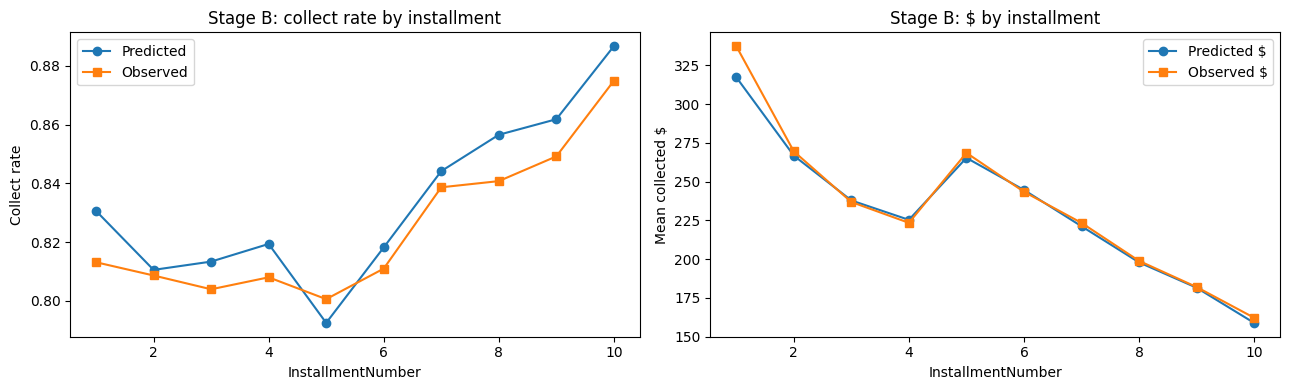

In [12]:
# Stage B: fit + evaluate.
from util.projection_stage_b import fit_stage_b, predict_expected_amount, evaluate_stage_b
from util.projection_plots import plot_stage_b_calibration

stage_b = fit_stage_b(
    seq_base=seq_base,
    features=STAGE_B_FEATURES,
    collected_col='collected_flag_k',
    amount_col='collected_amount_k',
)
print(f'stage_b trained. train_rows={stage_b.train_rows:,}  holdout_rows={stage_b.holdout_rows:,}')

b_eval = evaluate_stage_b(stage_b, seq_base)
print(f'\nclassifier log-loss       : {b_eval["classifier_log_loss"]:.4f}')
print(f'classifier acc @ 0.5      : {b_eval["classifier_accuracy_at_0p5"]:.3f}')
print(f'regressor MAE ($|collected): {b_eval["regressor_mae"]:.2f}')
print(f'regressor R² ($|collected) : {b_eval["regressor_r2"]:.3f}')

calib = b_eval['per_installment_calibration']
print('\nper-installment calibration (first 10 installments):')
print(calib.head(10).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_stage_b_calibration(calib.head(10), ax=axes)
plt.tight_layout(); plt.show()

# Phase 4 — Stage C: empirical recovery curve (MVP)

For delinquent loans we bucket by `days_since_default` and compute the empirical mean recovery fraction. The MVP uses a single global curve (no segmentation by status / portfolio / 3rd-party vs arrangement); refinement later. This gives the simulator a simple lookup: given days-since-default, return expected recovery fraction of outstanding.


recovery curve summary:
   days_bucket  n_loans  mean_recovery_fraction  median_recovery_fraction
0        540.0     5699                   0.086                       0.0


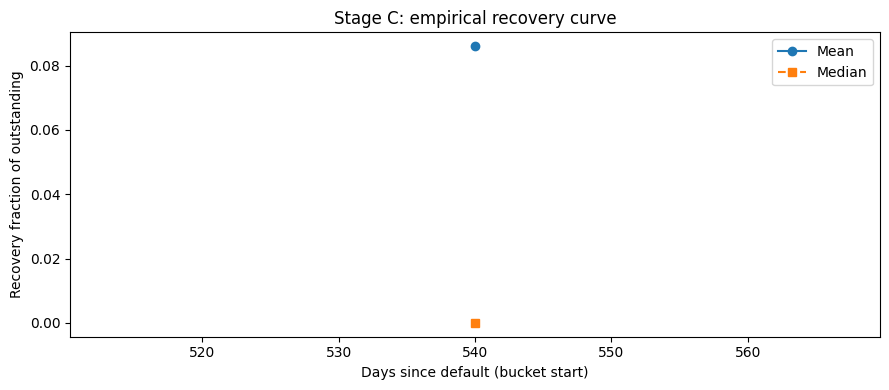


predicted vs realized recovery $ (delinquent pool):
       pred_recovery_amount  recovery_realized
count               8717.00            8717.00
mean                  33.96              60.82
std                   34.79             228.39
min                    0.00               0.00
25%                    0.00               0.00
50%                   27.54               0.00
75%                   58.10               0.00
max                  129.10            2833.22


In [13]:
# Stage C: build + inspect recovery curve.
from util.projection_stage_c import build_recovery_curve, predict_recovery_fraction, summarize_recovery_curve
from util.projection_plots import plot_recovery_curve

recovery_curve = build_recovery_curve(
    stage_c_base,
    days_col='days_since_default',
    outstanding_col='outstanding_at_default',
    recovery_col='recovery_realized',
    bucket_days=30,
    max_bucket_days=540,
    min_loans_per_bucket=20,
)
print('recovery curve summary:')
print(summarize_recovery_curve(recovery_curve).round(3))

fig, ax = plt.subplots(figsize=(9, 4))
plot_recovery_curve(recovery_curve.curve, ax=ax)
plt.tight_layout(); plt.show()

# Portfolio-level Stage C expected recovery: apply curve to each delinquent loan.
stage_c_base['pred_recovery_fraction'] = predict_recovery_fraction(
    recovery_curve,
    stage_c_base['days_since_default'].fillna(0).values,
    method='step',
)
stage_c_base['pred_recovery_amount'] = (
    stage_c_base['pred_recovery_fraction'] * stage_c_base['outstanding_at_default']
)
print('\npredicted vs realized recovery $ (delinquent pool):')
print(stage_c_base[['pred_recovery_amount', 'recovery_realized']].describe().round(2))

# Phase 5 — Portfolio projection + confidence narrowing

**The story for the team:**
At origination (k=0) we only know loan features. Our payin projection has wide confidence intervals.
As each installment matures (k=1, 2, 3, ...), we observe actual outcomes. These observations eliminate classes from the Stage A posterior (e.g., if installment 1 paid cleanly, FPD is ruled out). As the posterior sharpens, so does the projected payin distribution.

**MVP mechanics:**
1. Build a class → payin_ratio lookup from historical training data.
2. For each holdout loan, project payin via Monte Carlo: sample class ~ P(class|features), sample payin ~ N(μ_class, σ_class).
3. Roll up to dollar-weighted portfolio mean, with percentiles across sims.
4. Sweep k = 0, 1, 2, ... — at each k, update the posterior using observed installments from `seq_base`, re-simulate, plot CI width.

**What we're NOT doing yet (and why that's fine):**
- We're not using Stage B or Stage C inside each MC trajectory. They're trained and measured separately; folding them into the trajectory generator is the *next* iteration. For the stake-in-the-ground, the class-conditional approach already demonstrates the confidence-narrowing architecture — which is what the team needs to see.


In [14]:
# Stage B folded into the MC trajectory: each (loan, class) combination gets its own
# payin projection by summing Stage B's expected-$-if-collected over the installments
# the loan would be alive for under that class (pre-default for xPD, all installments
# for Clean, zero for DENY_NEW / ALL_VOIDED). This replaces the earlier class-average
# bootstrap lookup as the primary Monte Carlo sampler.
import importlib
import util.projection_simulator as _psim
import util.projection_stage_c as _pstc
importlib.reload(_psim)
importlib.reload(_pstc)

from util.projection_simulator import (
    build_class_payin_lookup,
    build_loan_class_payin_matrix,
    simulate_portfolio_ci_stage_b,
    bayes_update_stage_a,
    observed_outcomes_from_seq_base,
    apply_stage_c_recovery,
)
from util.projection_stage_c import (
    compute_terminal_recovery_by_class,
    broadcast_class_recovery_to_matrix,
)

# Class-average lookup kept around only for QC / stakeholder-facing summary.
payin_lookup = build_class_payin_lookup(
    loan_base,
    payin_col='payin_ratio_realized',
    class_col='payoff_type_collapsed',
)
print('class -> payin summary (training data only, QC reference):')
print(payin_lookup.table.round(3))

# Holdout slice = the portfolio we'll project.
holdout_loans = loan_base[loan_base['is_training_eligible'] & loan_base['is_holdout']].copy()
holdout_seq = seq_base[seq_base['LoanID'].isin(set(holdout_loans['LoanID']))].copy()
print(f'\nholdout portfolio: {len(holdout_loans):,} loans, '
      f'orig $ = {holdout_loans["OriginatedAmount"].sum()/1e6:.2f}M')

# Stage A posterior at origination (k=0).
probs_k0 = predict_proba(stage_a, holdout_loans)
probs_k0.index = holdout_loans['LoanID'].values
print('\nmean P(class) at k=0 (holdout):')
print(probs_k0.mean().round(3))

# Per-(loan, class) payin from Stage B (pre-default only; xPD cells exclude the
# post-default window and Clean spans all installments).
payin_matrix = build_loan_class_payin_matrix(
    holdout_loans,
    holdout_seq,
    stage_b,
)
print('\npayin_matrix class means (Stage B only, pre-recovery):')
print(payin_matrix.mean().round(3))

# Tier 3 (Option 1): add empirical Stage C post-default recovery on top.
# Recovery fractions come from matured (>= 180d) defaulted *training* loans,
# per collapsed xPD class. Clean / DENY_NEW / ALL_VOIDED get 0 by construction.
# Option 2 (per-loan recovery model) will plug into the same apply step.
recovery_by_class = compute_terminal_recovery_by_class(
    stage_c_base,
    loan_base,
    min_days_since_default=180,
    train_only=True,
)
print('\nterminal recovery fraction by class (matured training defaulted loans):')
print(pd.Series(recovery_by_class).round(3))

recovery_frac_matrix = broadcast_class_recovery_to_matrix(recovery_by_class, like=payin_matrix)
payin_matrix = apply_stage_c_recovery(payin_matrix, recovery_frac_matrix)

print('\npayin_matrix class means (after Stage C recovery):')
print(payin_matrix.mean().round(3))

k0 = simulate_portfolio_ci_stage_b(
    probs_k0,
    holdout_loans.set_index('LoanID')['OriginatedAmount'],
    payin_matrix,
    n_sims=500,
)
realized_portfolio = (
    (holdout_loans['OriginatedAmount'] * holdout_loans['payin_ratio_realized']).sum()
    / holdout_loans['OriginatedAmount'].sum()
)
print(f'\nk=0 portfolio projection: mean={k0["mean"]:.3f}, 90% CI=[{k0["lo05"]:.3f}, {k0["hi95"]:.3f}]')
print(f'realized portfolio payin : {realized_portfolio:.3f}')
print(f'k=0 CI width              : {k0["hi95"] - k0["lo05"]:.3f}')

class -> payin summary (training data only, QC reference):
        class      n   mean    std    q05    q50    q95
0         FPD  12857  0.120  0.357  0.000  0.000  1.117
1         SPD  11354  0.472  0.448  0.175  0.300  1.642
2         TPD   8110  0.779  0.492  0.300  0.600  1.950
3      LatePD  30272  1.816  0.988  0.600  1.600  3.681
4       Clean  81038  2.111  1.170  1.000  1.579  4.150
5    DENY_NEW      0  0.000  0.000  0.000  0.000  0.000
6  ALL_VOIDED      0  0.000  0.000  0.000  0.000  0.000

holdout portfolio: 35,897 loans, orig $ = 28.91M

mean P(class) at k=0 (holdout):
P_FPD           0.098
P_SPD           0.083
P_TPD           0.061
P_LatePD        0.200
P_Clean         0.559
P_DENY_NEW      0.000
P_ALL_VOIDED    0.000
dtype: float32

payin_matrix class means (Stage B only, pre-recovery):
FPD           0.000
SPD           0.487
TPD           0.808
LatePD        1.035
Clean         1.787
DENY_NEW      0.000
ALL_VOIDED    0.000
dtype: float64
[stage_c] terminal recovery po

--- Hard Bayesian update (indicator likelihood) ---
[hard] k=0: mean=1.237  CI=[1.229, 1.244]  width=0.015
[hard] k=1: mean=1.315  CI=[1.309, 1.321]  width=0.013
[hard] k=2: mean=1.316  CI=[1.310, 1.321]  width=0.011
[hard] k=3: mean=1.303  CI=[1.297, 1.308]  width=0.010
[hard] k=4: mean=1.274  CI=[1.269, 1.279]  width=0.010
[hard] k=5: mean=1.242  CI=[1.237, 1.247]  width=0.009
[hard] k=6: mean=1.215  CI=[1.210, 1.219]  width=0.009

--- Soft Bayesian update (Stage B p_collected as likelihood) ---
[soft] k=0: mean=1.237  CI=[1.229, 1.244]  width=0.015
[soft] k=1: mean=1.315  CI=[1.309, 1.321]  width=0.013
[soft] k=2: mean=1.316  CI=[1.310, 1.321]  width=0.011
[soft] k=3: mean=1.303  CI=[1.297, 1.308]  width=0.010
[soft] k=4: mean=1.248  CI=[1.243, 1.253]  width=0.010
[soft] k=5: mean=1.194  CI=[1.190, 1.199]  width=0.009
[soft] k=6: mean=1.158  CI=[1.153, 1.162]  width=0.009


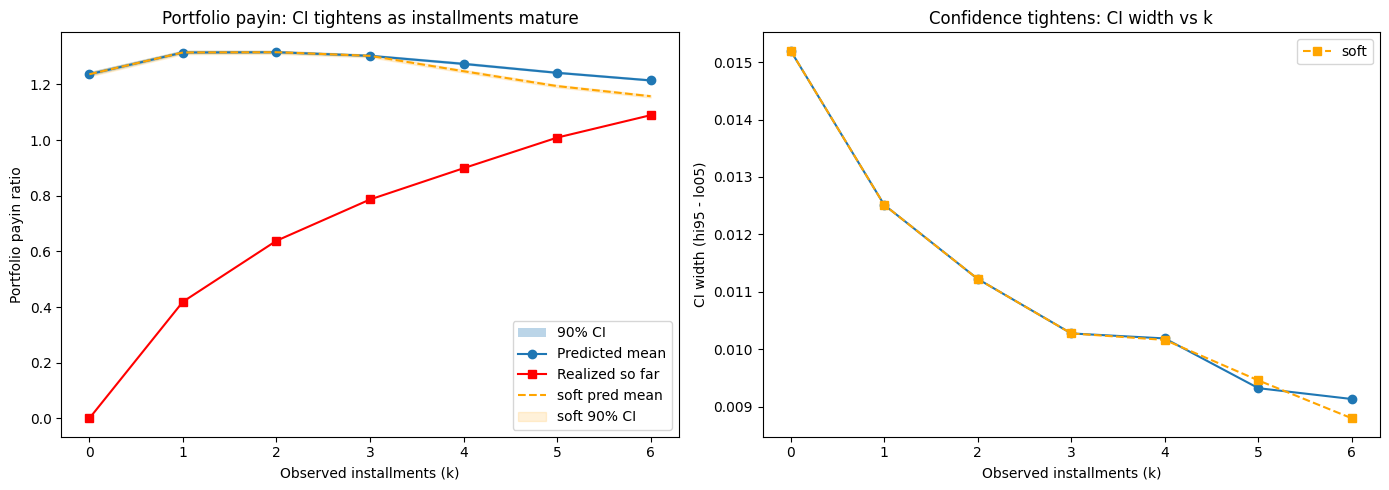


=== Narrative for the team ===
[hard] k=0: mean=1.237 width=0.015   k=6: mean=1.215 width=0.009   shrinkage=39.9%
[soft] k=0: mean=1.237 width=0.015   k=6: mean=1.158 width=0.009   shrinkage=42.1%
Realized (actual)       : 1.385


In [15]:
# Sweep k = 0..K_max, applying Bayesian update at each k, and plot the CI narrowing.
# We run two posterior updates in parallel to compare:
#   - Hard update (existing)  : bayes_update_stage_a, indicator likelihood.
#   - Soft update (Tier 2 new): bayes_update_stage_a_soft, Stage B p_collected as likelihood.
from util.projection_simulator import bayes_update_stage_a_soft
from util.projection_stage_b import predict_expected_amount
from util.projection_plots import plot_portfolio_ci_narrowing, plot_portfolio_ci_width_vs_k

K_MAX = 6  #tune as needed.

# Score Stage B once on the holdout sequence -> p_collected per (LoanID, InstallmentNumber).
# Reused for the soft Bayesian update at every k.
_stage_b_preds = predict_expected_amount(stage_b, holdout_seq)
holdout_seq_scored = holdout_seq[['LoanID', 'InstallmentNumber', 'collected_flag_k']].copy()
holdout_seq_scored['p_collected'] = _stage_b_preds['p_collected'].values

# Cumulative realized payin through installment k (same formula as the sanity-check cell).
# Independent of hard/soft update, so compute once and reuse across both sweeps.
orig_total = holdout_loans['OriginatedAmount'].sum()
realized_so_far_by_k = {
    k: holdout_seq.loc[holdout_seq['InstallmentNumber'] <= k, 'InstallRealizedPayment'].sum() / orig_total
    for k in range(0, K_MAX + 1)
}


def _run_sweep(update_fn, label):
    rows = []
    for k in range(0, K_MAX + 1):
        if k == 0:
            probs_k = probs_k0.copy()
        else:
            observations = observed_outcomes_from_seq_base(holdout_seq, holdout_loans, k=k)
            if update_fn is bayes_update_stage_a:
                probs_k = update_fn(probs_k0, observations.reindex(probs_k0.index))
            else:
                probs_k = update_fn(
                    probs_k0,
                    observations.reindex(probs_k0.index),
                    holdout_seq_scored,
                )
        sim = simulate_portfolio_ci_stage_b(
            probs_k,
            holdout_loans.set_index('LoanID')['OriginatedAmount'],
            payin_matrix,
            n_sims=500,
            rng_seed=42 + k,
        )
        rows.append({
            'k': k,
            'pred_mean': sim['mean'],
            'pred_lo05': sim['lo05'],
            'pred_hi95': sim['hi95'],
            'realized_so_far': realized_so_far_by_k[k],
        })
        print(f'[{label}] k={k}: mean={sim["mean"]:.3f}  '
              f'CI=[{sim["lo05"]:.3f}, {sim["hi95"]:.3f}]  '
              f'width={sim["hi95"] - sim["lo05"]:.3f}')
    return pd.DataFrame(rows)


print('--- Hard Bayesian update (indicator likelihood) ---')
ci_by_k_hard = _run_sweep(bayes_update_stage_a, 'hard')
print('\n--- Soft Bayesian update (Stage B p_collected as likelihood) ---')
ci_by_k_soft = _run_sweep(bayes_update_stage_a_soft, 'soft')

# Keep the old variable name pointing at the hard sweep for downstream cells.
ci_by_k = ci_by_k_hard

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_portfolio_ci_narrowing(ci_by_k_hard, ax=axes[0])
plot_portfolio_ci_width_vs_k(ci_by_k_hard, ax=axes[1])
axes[0].plot(ci_by_k_soft['k'], ci_by_k_soft['pred_mean'], '--', color='orange', label='soft pred mean')
axes[0].fill_between(ci_by_k_soft['k'], ci_by_k_soft['pred_lo05'], ci_by_k_soft['pred_hi95'],
                     alpha=0.15, color='orange', label='soft 90% CI')
axes[0].legend()
axes[1].plot(ci_by_k_soft['k'], ci_by_k_soft['pred_hi95'] - ci_by_k_soft['pred_lo05'],
             '--', color='orange', marker='s', label='soft')
axes[1].legend()
plt.tight_layout(); plt.show()

print('\n=== Narrative for the team ===')
for label, frame in [('hard', ci_by_k_hard), ('soft', ci_by_k_soft)]:
    w0 = frame.iloc[0]['pred_hi95'] - frame.iloc[0]['pred_lo05']
    wk = frame.iloc[-1]['pred_hi95'] - frame.iloc[-1]['pred_lo05']
    reduction = 1 - wk / max(w0, 1e-9)
    print(f'[{label}] k=0: mean={frame.iloc[0]["pred_mean"]:.3f} width={w0:.3f}   '
          f'k={K_MAX}: mean={frame.iloc[-1]["pred_mean"]:.3f} width={wk:.3f}   '
          f'shrinkage={reduction:.1%}')
print(f'Realized (actual)       : {realized_portfolio:.3f}')

 k  cum_realized_payin
 0               0.000
 1               0.419
 2               0.638
 3               0.787
 4               0.899
 5               1.009
 6               1.090


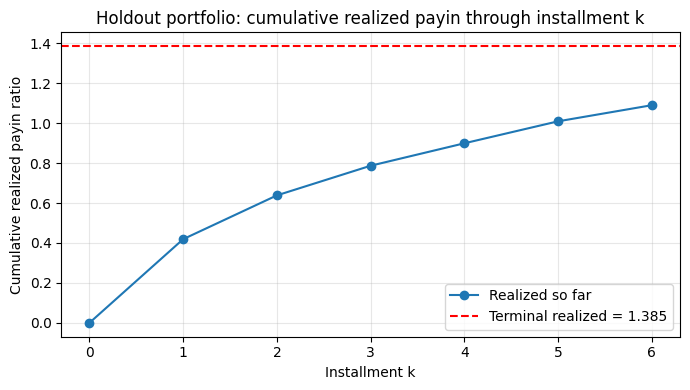

In [21]:
# Sanity check: cumulative realized payin across holdout, by installment k.
holdout_lids = set(holdout_loans['LoanID'])
hseq = seq_base.loc[seq_base['LoanID'].isin(holdout_lids), ['LoanID', 'InstallmentNumber', 'InstallRealizedPayment']]
orig_total = holdout_loans['OriginatedAmount'].sum()

ks = list(range(0, 7))
cum = [hseq.loc[hseq['InstallmentNumber'] <= k, 'InstallRealizedPayment'].sum() / orig_total for k in ks]

print(pd.DataFrame({'k': ks, 'cum_realized_payin': cum}).round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, cum, marker='o', label='Realized so far')
ax.axhline(realized_portfolio, ls='--', color='red', label=f'Terminal realized = {realized_portfolio:.3f}')
ax.set_xlabel('Installment k'); ax.set_ylabel('Cumulative realized payin ratio')
ax.set_title('Holdout portfolio: cumulative realized payin through installment k')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# MVP summary + what's next

**What's now running end-to-end:**
- Stage A: XGBoost multinomial, 7-class payoff_type — fit, evaluated, calibrated.
- Stage B: LightGBM binary + regressor — fit and per-installment calibration on holdout.
- Stage C: empirical recovery curve over `days_since_default` — fit and applied to delinquent pool.
- Portfolio simulator: Monte Carlo over Stage A posterior + class-conditional payin lookup.
- Bayesian update: observed installment outcomes sharpen the Stage A posterior, CI narrows with k.

**Known MVP simplifications (decision log for the team):**
1. *Stage B is measured but not yet consumed inside the MC trajectory.* The simulator uses class-conditional payin lookup rather than per-installment sampling. Folding Stage B into the trajectory generator is the first refinement target.
2. *Bayesian update is "hard compatibility" (indicator likelihood).* Classes incompatible with observations get zero mass. Soft likelihoods using Stage B output come next.
3. *Stage C uses a single global recovery curve.* No segmentation by portfolio, LoanStatus, or arrangement vs 3rd-party. Enhancement when we revisit.
4. *Class-conditional payin std is empirical.* If a class has small `n`, σ collapses to 0 and the CI is artificially tight for that class. Regularize later.

**Refinement backlog (ordered by impact on the CI story):**
- Fold Stage B expected amount into per-installment MC trajectories.
- Soft likelihood updates from Stage B p_collected + e_amount.
- Stage C segmentation (3rd-party vs arrangement; LoanStatus).
- Re-check class-conditional payin distributions; consider Beta fits rather than Normal-clipped.
- Swap empirical lookup with a payin-ratio regressor conditioned on class for loan-specific predictions.

**For the team presentation:**
The two plots at the end of Phase 5 are the key visuals:
- left: portfolio payin projection — mean + 90% CI — tightening around the realized value as k grows.
- right: CI width shrinking vs k — the "confidence story" quantified.
